# Testing Market Efficiency Using Historical Returns

*Quant Lab · The Analytical Investor · Year 1, Month 7*

**Read the article:** [Testing Market Efficiency Using Historical Returns](https://analytical-investor.blog/?p=1015)

Three weak-form efficiency tests on a series with a small, deliberately injected trend: autocorrelation, variance ratios, and a simple timing rule.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
Build the series and run all three tests.

In [2]:
import numpy as np

rng = np.random.default_rng(11)

# ------------------------------------------------------------------
# 1. Build a daily return series with mild injected momentum
# ------------------------------------------------------------------
n_days = 252 * 30                      # thirty years of trading days
mu, sigma, rho = 0.07/252, 0.16/np.sqrt(252), 0.05   # rho = AR(1) strength

eps = rng.standard_t(5, n_days)
eps *= sigma / np.sqrt(5/3)
r = np.empty(n_days)
r[0] = mu + eps[0]
for t in range(1, n_days):
    r[t] = mu + rho * (r[t-1] - mu) + eps[t]   # AR(1): weak trending

# ------------------------------------------------------------------
# 2. Test 1 — autocorrelation of returns
# ------------------------------------------------------------------
def autocorr(x, lag):
    x = x - x.mean()
    return (x[:-lag] * x[lag:]).sum() / (x**2).sum()

print("Lag  Autocorr   |ac| > 2/sqrt(N)?")
bound = 2 / np.sqrt(n_days)            # ~95% band under the null
for lag in (1, 2, 5, 10, 21):
    ac = autocorr(r, lag)
    print(f"{lag:>3}  {ac:>8.4f}   {'YES' if abs(ac) > bound else 'no'}")

# ------------------------------------------------------------------
# 3. Test 2 — variance ratio (Lo–MacKinlay style, simplified)
# ------------------------------------------------------------------
def variance_ratio(x, q):
    n = len(x) // q * q
    single = np.var(x[:n], ddof=1)
    agg = np.var(x[:n].reshape(-1, q).sum(axis=1), ddof=1)
    return agg / (q * single)

print("\nHorizon(q)  VR   (1 = random walk)")
for q in (2, 5, 21, 63):
    print(f"{q:>9}  {variance_ratio(r, q):.3f}")

# ------------------------------------------------------------------
# 4. Test 3 — momentum rule backtest vs buy-and-hold
#    Rule: hold the market if past-63-day return > 0, else cash
# ------------------------------------------------------------------
look, cost = 63, 0.0005                # 5 bp per switch
sig = np.array([1 if r[max(0,t-look):t].sum() > 0 else 0
                for t in range(n_days)])
switches = np.abs(np.diff(sig, prepend=sig[0]))
strat = sig * r - switches * cost

def ann(x): return x.mean()*252, x.std()*np.sqrt(252)

(m_b, s_b), (m_s, s_s) = ann(r), ann(strat)
print(f"\nBuy & hold : ret {m_b:.2%}, vol {s_b:.2%}, Sharpe {m_b/s_b:.2f}")
print(f"Momentum   : ret {m_s:.2%}, vol {s_s:.2%}, Sharpe {m_s/s_s:.2f}")
print(f"Time in market: {sig.mean():.0%},  switches: {switches.sum():.0f}")

Lag  Autocorr   |ac| > 2/sqrt(N)?
  1    0.0426   YES
  2   -0.0102   no
  5   -0.0015   no
 10   -0.0117   no
 21    0.0007   no

Horizon(q)  VR   (1 = random walk)
        2  1.047
        5  1.094
       21  1.035
       63  1.170

Buy & hold : ret 2.68%, vol 15.95%, Sharpe 0.17
Momentum   : ret 0.64%, vol 11.83%, Sharpe 0.05
Time in market: 53%,  switches: 459


### Autocorrelation against the noise band
Bars outside the dashed band are statistically significant. Detecting a pattern is not the same as profiting from it.

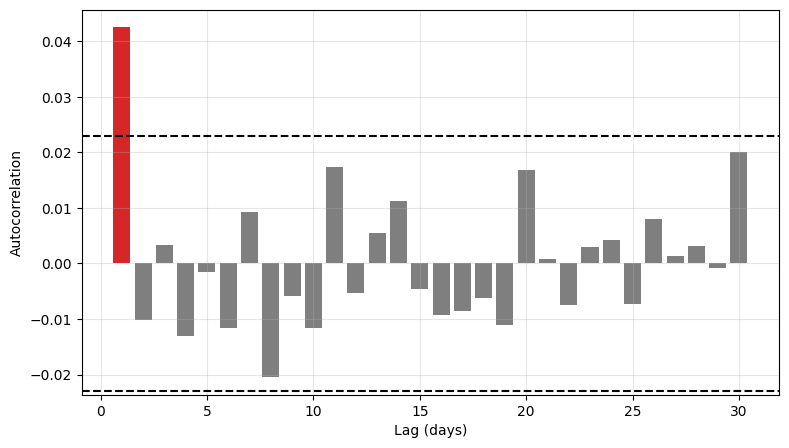

In [3]:
lags = np.arange(1, 31)
acs = [autocorr(r, L) for L in lags]
plt.bar(lags, acs, color=["tab:red" if abs(x) > bound else "tab:gray" for x in acs])
plt.axhline(bound, ls="--", color="k"); plt.axhline(-bound, ls="--", color="k")
plt.xlabel("Lag (days)"); plt.ylabel("Autocorrelation"); plt.show()

## The same thing with the toolkit
The model above lives in the `analytical_investor` package, tested and reusable.

In [4]:
from analytical_investor import efficiency

# The luck audit from the article: rerun with no trend (rho = 0) across seeds
false_alarms = 0
for seed in range(20):
    x = np.random.default_rng(seed).normal(0, 0.01, n_days)
    if any(abs(efficiency.autocorrelation(x, L)) > bound for L in (1, 2, 5, 10, 21)):
        false_alarms += 1
print(f"Seeds with at least one 'significant' lag under pure noise: {false_alarms}/20")

Seeds with at least one 'significant' lag under pure noise: 5/20


---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=1015).